In [35]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [36]:
catalog_dir = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/Earthquake_Catalog/")
results = []

In [37]:
def estimate_mc_maxc(magnitudes, bin_size=0.1):
    mags = np.array(magnitudes)
    bins = np.arange(mags.min(), mags.max() + bin_size, bin_size)
    counts, edges = np.histogram(mags, bins=bins)
    mc = edges[np.argmax(counts)] + 0.1
    return round(mc, 1)

def estimate_mc_mbs(magnitudes, bin_size=0.1, min_events=20):
    mags = np.array(magnitudes)
    mc_candidates = np.arange(mags.min(), mags.max() - 0.5, bin_size)
    b_values = []
    for mc in mc_candidates:
        above = mags[mags >= mc]
        if len(above) < min_events:
            b_values.append(np.nan)
            continue
        b = np.log10(np.e) / (np.mean(above) - mc + bin_size/2)
        b_values.append(b)
    b_values = np.array(b_values)
    for i in range(len(b_values) - 4):
        window = b_values[i:i+5]
        if not np.any(np.isnan(window)) and np.std(window) < 0.1:
            return round(mc_candidates[i], 1)
    valid_idx = np.where(~np.isnan(b_values))[0]
    return round(mc_candidates[valid_idx[0]], 1) if len(valid_idx) > 0 else np.nan

def estimate_bvalue(magnitudes, mc, bin_size=0.1):
    above = np.array(magnitudes)
    above = above[above >= mc]
    if len(above) < 20:
        return np.nan, np.nan
    b = np.log10(np.e) / (np.mean(above) - mc + bin_size/2)
    sigma_b = b / np.sqrt(len(above))
    return round(b, 3), round(sigma_b, 3)

In [38]:
# Manual Mc overrides where automatic methods fail
# Chile and Australia need higher Mc due to catalog incompleteness
MC_OVERRIDES = {
    "Central_Chile": 3.5,      # b-value diagnostic suggests catalog incomplete below 3.5
    "Western_Australia": 3.0,  # too few events for reliable low-Mc estimate
}

results = []
MIN_EVENTS = 50

for f in sorted(catalog_dir.glob("*.csv")):
    df = pd.read_csv(f)
    mags = df['mag'].dropna().values

    if len(mags) < MIN_EVENTS:
        results.append({
            'patch': f.stem, 'n_events': len(mags),
            'mc_maxc': np.nan, 'mc_mbs': np.nan,
            'mc_consensus': np.nan, 'mc_override': np.nan,
            'mc_final': np.nan, 'b_value': np.nan,
            'b_sigma': np.nan, 'n_above_mc': np.nan,
            'status': 'too_sparse'
        })
        continue

    mc_maxc = estimate_mc_maxc(mags)
    mc_mbs  = estimate_mc_mbs(mags)
    mc_consensus = round(np.mean([mc_maxc, mc_mbs]), 1)

    # Apply override if flagged
    patch_name = f.stem
    mc_override = MC_OVERRIDES.get(patch_name, np.nan)
    mc_final = mc_override if not np.isnan(mc_override) else mc_consensus

    b, b_sigma = estimate_bvalue(mags, mc_final)
    n_above = int((mags >= mc_final).sum())

    results.append({
        'patch': patch_name, 'n_events': len(mags),
        'mc_maxc': mc_maxc, 'mc_mbs': mc_mbs,
        'mc_consensus': mc_consensus,
        'mc_override': mc_override,
        'mc_final': mc_final,
        'b_value': b, 'b_sigma': b_sigma,
        'n_above_mc': n_above,
        'status': 'override' if not np.isnan(mc_override) else 'ok'
    })

results_df = pd.DataFrame(results)
print("="*90)
print("REVISED Mc SUMMARY (MAXC + MBS consensus, GFT dropped)")
print("="*90)
print(results_df[[
    'patch', 'n_events', 'mc_maxc', 'mc_mbs', 'mc_consensus',
    'mc_override', 'mc_final', 'b_value', 'b_sigma', 'n_above_mc', 'status'
]].to_string(index=False))

REVISED Mc SUMMARY (MAXC + MBS consensus, GFT dropped)
                     patch  n_events  mc_maxc  mc_mbs  mc_consensus  mc_override  mc_final  b_value  b_sigma  n_above_mc     status
             Central_Chile      2597      2.8     2.5           2.6          3.5       3.5    0.463    0.012      1574.0   override
             Central_Nepal       409      4.1     3.4           3.8          NaN       3.8    0.613    0.031       393.0         ok
            Central_Turkey       750      4.3     2.7           3.5          NaN       3.5    0.460    0.017       712.0         ok
               Kanto_Japan      3149      4.4     3.0           3.7          NaN       3.7    0.501    0.009      3074.0         ok
                Kuch_India        32      NaN     NaN           NaN          NaN       NaN      NaN      NaN         NaN too_sparse
           North_Island_NZ      1470      4.0     2.6           3.3          NaN       3.3    0.470    0.012      1469.0         ok
               Ordos_

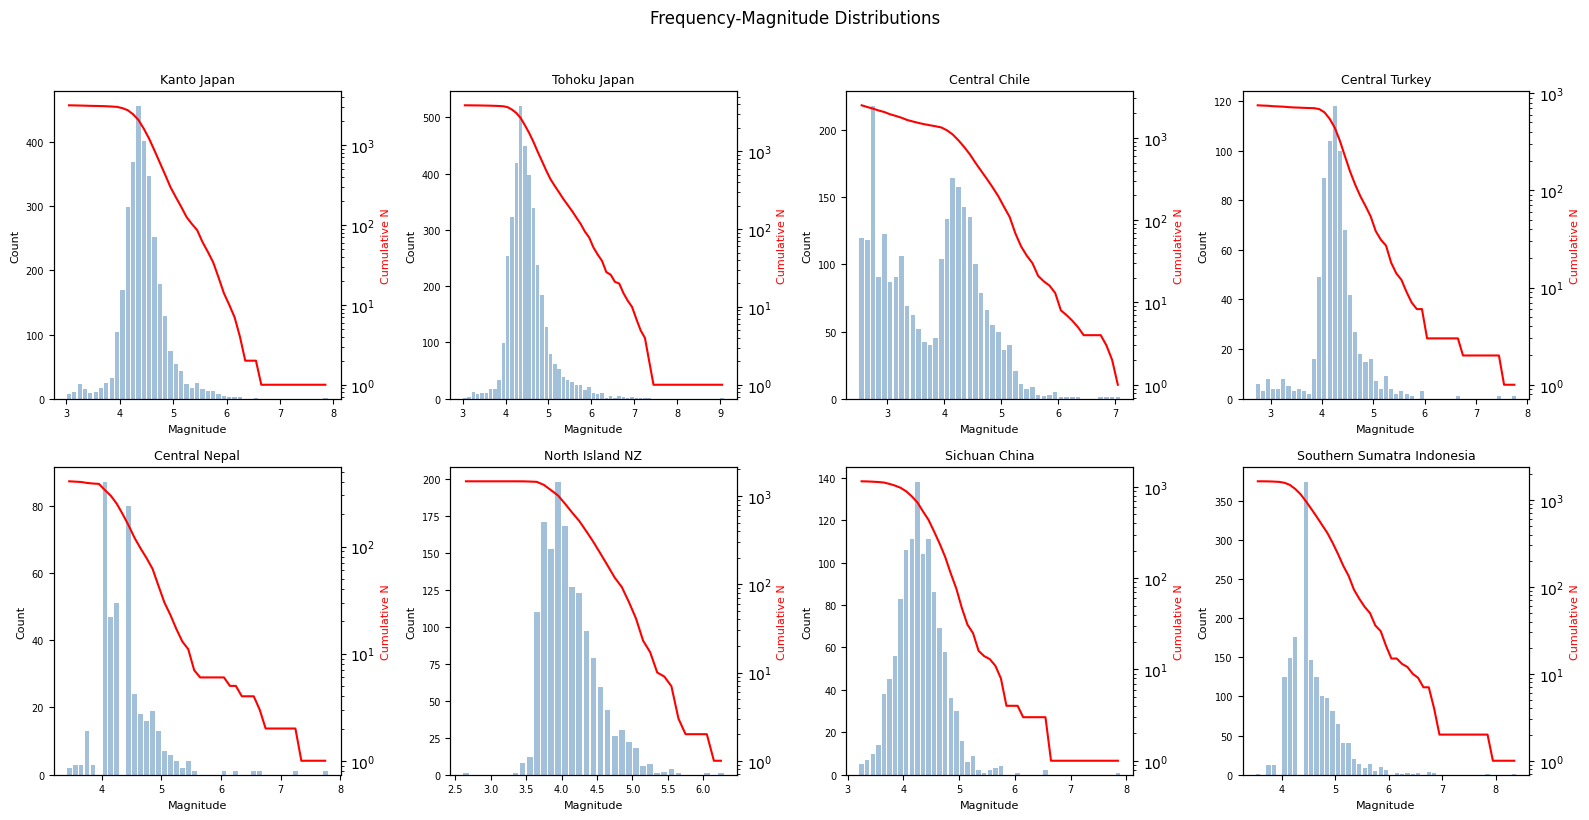

In [39]:
# Plot FMD for all healthy patches
patches_to_plot = [
    "Kanto_Japan", "Tohoku_Japan", "Central_Chile",
    "Central_Turkey", "Central_Nepal", "North_Island_NZ",
    "Sichuan_China", "Southern_Sumatra_Indonesia"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, patch_name in enumerate(patches_to_plot):
    f = catalog_dir / f"{patch_name}.csv"
    if not f.exists():
        continue
    
    df = pd.read_csv(f)
    mags = df['mag'].dropna().values
    
    bin_size = 0.1
    bins = np.arange(mags.min(), mags.max() + bin_size, bin_size)
    counts, edges = np.histogram(mags, bins=bins)
    bin_centers = edges[:-1] + bin_size/2
    
    # Cumulative (G-R plot)
    cumulative = np.array([np.sum(mags >= m) for m in bin_centers])
    
    ax = axes[idx]
    # Incremental
    ax.bar(bin_centers, counts, width=bin_size*0.8, 
           alpha=0.5, color='steelblue', label='Incremental')
    # Cumulative
    ax2 = ax.twinx()
    ax2.semilogy(bin_centers, cumulative, 'r-', linewidth=1.5, label='Cumulative')
    ax2.set_ylabel('Cumulative N', color='red', fontsize=8)
    
    ax.set_title(patch_name.replace('_', ' '), fontsize=9)
    ax.set_xlabel('Magnitude', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Frequency-Magnitude Distributions', fontsize=12, y=1.02)
plt.tight_layout()
#plt.savefig("data/fmd_plots.png", dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Visually confirmed Mc values from FMD inspection
MC_FINAL = {
    "Kanto_Japan":                  4.4,
    "Tohoku_Japan":                 4.4,
    "Central_Chile":                4.0,
    "Central_Turkey":               4.3,
    "Central_Nepal":                4.4,
    "North_Island_NZ":              3.5,
    "Sichuan_China":                4.3,
    "Southern_Sumatra_Indonesia":   4.5,
    "Western_Australia":            3.0,  # retain override — too sparse to read FMD
    "Kuch_India":                   4.0,  # literature estimate
    "Ordos_China":                  4.0,  # literature estimate
    "Southern_Norway":              2.5,  # literature estimate
}

def estimate_bvalue(magnitudes, mc, bin_size=0.1):
    above = np.array(magnitudes)
    above = above[above >= mc]
    if len(above) < 20:
        return np.nan, np.nan
    b = np.log10(np.e) / (np.mean(above) - mc + bin_size/2)
    sigma_b = b / np.sqrt(len(above))
    return round(b, 3), round(sigma_b, 3)

catalog_dir = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/Earthquake_Catalog/")

results = []
for f in sorted(catalog_dir.glob("*.csv")):
    df = pd.read_csv(f)
    mags = df['mag'].dropna().values
    patch = f.stem
    mc = MC_FINAL.get(patch, np.nan)
    
    b, b_sigma = estimate_bvalue(mags, mc)
    n_above = int((mags >= mc).sum()) if not np.isnan(mc) else np.nan
    
    method = 'visual_fmd' if patch in [
        "Kanto_Japan", "Tohoku_Japan", "Central_Chile",
        "Central_Turkey", "Central_Nepal", "North_Island_NZ",
        "Sichuan_China", "Southern_Sumatra_Indonesia"
    ] else 'literature'
    
    results.append({
        'patch': patch,
        'n_events': len(mags),
        'mc_final': mc,
        'mc_method': method,
        'b_value': b,
        'b_sigma': b_sigma,
        'n_above_mc': n_above,
    })

results_df = pd.DataFrame(results)
print("="*80)
print("FINAL Mc TABLE (visually confirmed from FMD)")
print("="*80)
print(results_df.to_string(index=False))

FINAL Mc TABLE (visually confirmed from FMD)
                     patch  n_events  mc_final  mc_method  b_value  b_sigma  n_above_mc
             Central_Chile      2597       4.0 visual_fmd    0.769    0.021        1333
             Central_Nepal       409       4.4 visual_fmd    1.048    0.074         200
            Central_Turkey       750       4.3 visual_fmd    1.317    0.063         442
               Kanto_Japan      3149       4.4 visual_fmd    1.289    0.028        2061
                Kuch_India        32       4.0 literature    0.827    0.156          28
           North_Island_NZ      1470       3.5 visual_fmd    0.600    0.016        1468
               Ordos_China        30       4.0 literature    1.790    0.345          27
             Sichuan_China      1154       4.3 visual_fmd    1.204    0.046         679
           Southern_Norway         4       2.5 literature      NaN      NaN           4
Southern_Sumatra_Indonesia      1642       4.5 visual_fmd    0.999    0.032

In [41]:
def estimate_bvalue(magnitudes, mc, bin_size=0.1):
    above = np.array(magnitudes)
    above = above[above >= mc]
    if len(above) < 20:
        return np.nan, np.nan, len(above)
    b = np.log10(np.e) / (np.mean(above) - mc + bin_size/2)
    sigma_b = b / np.sqrt(len(above))
    return round(b, 3), round(sigma_b, 3), len(above)

df_nz = pd.read_csv("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/Earthquake_Catalog/North_Island_NZ.csv")
mags = df_nz['mag'].dropna().values

print("NZ b-value sensitivity to Mc:")
print(f"{'Mc':>6} {'b':>8} {'b_sigma':>8} {'N_above':>8}")
print("-" * 35)
for mc in [3.5, 3.8, 4.0, 4.2, 4.5]:
    b, sig, n = estimate_bvalue(mags, mc)
    print(f"{mc:>6.1f} {b:>8.3f} {sig:>8.3f} {n:>8}")

NZ b-value sensitivity to Mc:
    Mc        b  b_sigma  N_above
-----------------------------------
   3.5    0.600    0.016     1468
   3.8    0.920    0.025     1338
   4.0    1.109    0.035     1014
   4.2    1.211    0.048      648
   4.5    1.405    0.081      301


## Final Analysis

In [42]:
def estimate_bvalue(magnitudes, mc, bin_size=0.1):
    above = np.array(magnitudes)
    above = above[above >= mc]
    if len(above) < 20:
        return np.nan, np.nan
    b = np.log10(np.e) / (np.mean(above) - mc + bin_size/2)
    sigma_b = b / np.sqrt(len(above))
    return round(b, 3), round(sigma_b, 3)

# Final confirmed Mc values
MC_FINAL = {
    "Kanto_Japan":                  4.4,
    "Tohoku_Japan":                 4.4,
    "Central_Chile":                4.0,
    "Central_Turkey":               4.3,
    "Central_Nepal":                4.4,
    "North_Island_NZ":              4.0,  # updated from 3.5 — mixed population below 4.0
    "Sichuan_China":                4.3,
    "Southern_Sumatra_Indonesia":   4.5,
    "Western_Australia":            3.0,
    "Kuch_India":                   4.0,
    "Ordos_China":                  4.0,
    "Southern_Norway":              2.5,
}

MC_METHOD = {
    "Kanto_Japan":                  "visual_fmd",
    "Tohoku_Japan":                 "visual_fmd",
    "Central_Chile":                "visual_fmd",
    "Central_Turkey":               "visual_fmd",
    "Central_Nepal":                "visual_fmd",
    "North_Island_NZ":              "visual_fmd + b-value stability",
    "Sichuan_China":                "visual_fmd",
    "Southern_Sumatra_Indonesia":   "visual_fmd",
    "Western_Australia":            "literature",
    "Kuch_India":                   "literature",
    "Ordos_China":                  "literature",
    "Southern_Norway":              "literature",
}

B_FLAGS = {
    "Central_Chile":      "uncertain — aftershock mixing",
    "Western_Australia":  "unreliable — N<50 above Mc",
    "Ordos_China":        "unreliable — N<30 above Mc",
    "Kuch_India":         "unreliable — N<30 above Mc",
    "Southern_Norway":    "unreliable — N<10 above Mc",
}

catalog_dir = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/Earthquake_Catalog/")
results = []

for f in sorted(catalog_dir.glob("*.csv")):
    df = pd.read_csv(f)
    mags = df['mag'].dropna().values
    patch = f.stem
    mc = MC_FINAL.get(patch, np.nan)
    method = MC_METHOD.get(patch, 'unknown')
    flag = B_FLAGS.get(patch, 'ok')

    b, b_sigma = estimate_bvalue(mags, mc)
    n_above = int((mags >= mc).sum()) if not np.isnan(mc) else np.nan

    results.append({
        'patch':       patch,
        'n_events':    len(mags),
        'mc_final':    mc,
        'mc_method':   method,
        'b_value':     b,
        'b_sigma':     b_sigma,
        'n_above_mc':  n_above,
        'b_flag':      flag,
    })

results_df = pd.DataFrame(results)
print("="*100)
print("FINAL Mc TABLE — confirmed")
print("="*100)
print(results_df.to_string(index=False))

results_df.to_csv("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/mc_final.csv", index=False)
print("data saved")

FINAL Mc TABLE — confirmed
                     patch  n_events  mc_final                      mc_method  b_value  b_sigma  n_above_mc                        b_flag
             Central_Chile      2597       4.0                     visual_fmd    0.769    0.021        1333 uncertain — aftershock mixing
             Central_Nepal       409       4.4                     visual_fmd    1.048    0.074         200                            ok
            Central_Turkey       750       4.3                     visual_fmd    1.317    0.063         442                            ok
               Kanto_Japan      3149       4.4                     visual_fmd    1.289    0.028        2061                            ok
                Kuch_India        32       4.0                     literature    0.827    0.156          28    unreliable — N<30 above Mc
           North_Island_NZ      1470       4.0 visual_fmd + b-value stability    1.109    0.035        1014                            ok
       

## Methods, Insights & Considerations (inc Limitations)

### Overview

<p>Magnitude of completeness (Mc) estimation was performed as the first catalog processing step, prior to any feature engineering or declustering. Mc represents the lowest magnitude threshold above which a seismic network detects earthquakes with near-uniform probability — the point below which the catalog becomes statistically incomplete due to instrumental sensitivity limits rather than absence of seismicity. Critically, the decision to trim catalogs to events ≥ Mc was framed not as a data reduction step but as a stationarity enforcement step: events below Mc have spatially and temporally variable detection probabilities driven by network geometry, which would introduce region-specific biases fundamentally incompatible with the cross-regional transfer objective. All temporal features in the model are computed on complete, unbiased samples whose statistical properties reflect tectonic process rather than instrumental sensitivity.</p>

### Methods Attempted

<p>Three standard automated Mc estimation methods were initially implemented and compared: Maximum Curvature (MAXC): Identifies Mc as the magnitude bin with the highest incremental event count, plus a small upward correction. Fast and intuitive but known to underestimate Mc in catalogs with gradual rolloff rather than a sharp peak. Goodness of Fit Test (GFT, Wiemer & Wyss 2000): Fits a Gutenberg-Richter line above successive Mc candidates and identifies the lowest Mc where the residual between observed and predicted counts falls below a 5% threshold. In practice the GFT implementation returned implausibly high Mc values across all patches (6.5–8.5) — the algorithm was failing to find a satisfactory fit and defaulting to the upper end of the candidate range. GFT results were therefore discarded and the method excluded from the consensus. b-value Stability (MBS, Cao & Gao 2002): Estimates the b-value of the Gutenberg-Richter relation in a sliding magnitude window and identifies Mc as the point where b stabilises. This method was more reliable than GFT but still showed sensitivity to catalog heterogeneity — the stability window was triggering too early in some patches before true completeness was reached.</p>

<p>Given the failure of GFT and the instability of MBS in several patches, automated consensus estimates were supplemented with visual inspection of frequency-magnitude distributions (FMDs) for all patches with sufficient event counts. FMD plots were produced showing both incremental (histogram) and cumulative (log-scale) event counts as a function of magnitude. Mc was read directly from the cumulative curve as the magnitude at which the distribution departs from log-linear behaviour — the standard visual diagnostic used in operational seismology. For patches where automated and visual estimates disagreed, the visual FMD estimate was preferred as it directly reflects the underlying data structure without algorithmic assumptions. For patches too sparse for automated or visual estimation (Southern Norway, Ordos China, Kutch India), Mc was assigned from published literature estimates for the respective regions and flagged accordingly.</p>

### Key Finding

<p>The most methodologically significant finding during Mc estimation was the identification of catalog heterogeneity in the New Zealand North Island patch. The GeoNet catalog is exceptionally complete down to Mw 3.5 — far better than USGS coverage for any other patch — but b-value sensitivity analysis revealed a dramatic jump from b=0.600 at Mc=3.5 to b=1.109 at Mc=4.0. This indicates that events in the Mw 3.5–4.0 range represent a mixed population including volcanic tremors and induced seismicity from the Taupo Volcanic Zone that follow a different magnitude-frequency scaling than the tectonic events above Mw 4.0. Including this mixed population would violate the Gutenberg-Richter assumption underlying the b-value feature and introduce a physically inconsistent signal into the temporal feature space. Mc for New Zealand was therefore set to 4.0 — not the network completeness limit but the threshold above which the catalog represents a stationary, physically homogeneous population.</p>


### Interpretation of b-values

<p>Across the seven patches with reliable b-value estimates, the range of 1.0–1.3 is physically coherent and consistent with published regional seismicity studies. Turkey (1.317) and Kanto (1.289) show elevated b-values consistent with highly heterogeneous stress fields in complex fault systems — the East Anatolian Fault and the dual-subduction Kanto setting respectively. Tohoku (1.034) and Sumatra (0.999) are close to the global average of ~1.0, consistent with mature megathrust interfaces under relatively uniform compressional stress. Nepal (1.048) is slightly above 1.0, reflecting the episodic nature of collision-zone seismicity where stress is released in large events with relatively fewer small events. Sichuan (1.204) is elevated, consistent with the complex thrust belt geometry of the Longmenshan system.</p>

<p>Chile (0.769) remains flagged as uncertain — the b-value is below the physically expected range for a megathrust setting and likely reflects contamination from the 2010 Maule and 2015 Illapel aftershock sequences creating a bimodal magnitude distribution that flattens the apparent G-R slope. The b-value for Chile will not be used as a static feature input and will be excluded from the frozen prior construction. The Mc=4.0 trimmed catalog will be used for temporal feature engineering but b-value-dependent features will be masked for this patch.</p>

<p>The b-value range across reliable patches also has direct relevance to the geological clustering step — b-value is a proxy for differential stress and fault heterogeneity, both of which are properties of the geological regime. The separation between the high-b patches (Turkey, Kanto, Sichuan) and the near-unity patches (Tohoku, Sumatra, Nepal) reflects a physically meaningful distinction between structurally complex fault systems and simpler convergent interfaces, adding a geomechanical dimension to the static feature space beyond what the remote-sensing layers alone capture.</p>

### Design decisions

<p>The choice to prioritise statistical stationarity over catalog volume — accepting fewer events above Mc rather than inflating event counts with incomplete small-magnitude data — reflects a deliberate alignment between the data processing philosophy and the model's cross-regional transfer objective. A model trained on statistically complete catalogs learns temporal dynamics governed by tectonic process. A model trained on mixed complete and incomplete catalogs learns a combination of tectonic dynamics and network geometry — the latter being entirely region-specific and therefore actively harmful to transfer. This framing positions Mc trimming not as a limitation of the dataset but as a principled design choice consistent with the broader goal of learning transferable, physically grounded representations of seismic hazard.</p>

